In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import datetime

### Load Dataset

In [3]:
orig_df = pd.read_csv("shampoo_sales.csv")
orig_df.head(5)

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


In [4]:
orig_df.shape

(36, 2)

In [5]:
orig_df.dtypes

Month     object
Sales    float64
dtype: object

In [6]:
df = orig_df.copy()

### Set time index

#### String Time Format Code List: https://strftime.org/

In [7]:
from datetime import datetime

def parser(x):
 return datetime.strptime('200'+x, '%Y-%m')

df['Month'] = df['Month'].apply(parser)
df.head()

,Month,Sales
0,2001-01-01,266.0
1,2001-02-01,145.9
2,2001-03-01,183.1
3,2001-04-01,119.3
4,2001-05-01,180.3


In [8]:
df.dtypes

Month    datetime64[ns]
Sales           float64
dtype: object

In [9]:
df = df.set_index('Month')
df.head()

,Sales
Month,
2001-01-01,266.0
2001-02-01,145.9
2001-03-01,183.1
2001-04-01,119.3
2001-05-01,180.3


In [10]:
df.columns

Index(['Sales'], dtype='object')

In [11]:
value_var = 'Sales'

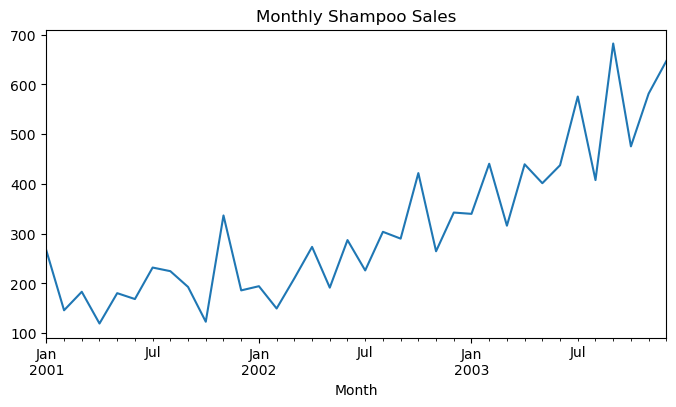

In [12]:
df[value_var].plot(title="Monthly Shampoo Sales", figsize=(8,4))
plt.show()

### Data Processing

In [13]:
# Detecting and removing outliers using Z-score
from scipy.stats import zscore
z_scores = zscore(df[value_var])
abs_z_scores = np.abs(z_scores)

zscore_threshold = 3 #any data above mean +/- (this_threshold)*sd is considered outliers
outliers = (abs_z_scores > zscore_threshold)  # Z-score threshold.
df = df.loc[~outliers].copy()

print(orig_df.shape)
print(df.shape)

df.head()

(36, 2)
(36, 1)


,Sales
Month,
2001-01-01,266.0
2001-02-01,145.9
2001-03-01,183.1
2001-04-01,119.3
2001-05-01,180.3


In [14]:
forecast_steps = 6  # Forecast duration

# because dataframe has only one column.  need to explicitly convert to dataframe
train_df = df[value_var][:-forecast_steps ].to_frame(name=value_var)
test_df  = df[value_var][-forecast_steps :].to_frame(name=value_var)
train_df

,Sales
Month,
2001-01-01,266.0
2001-02-01,145.9
2001-03-01,183.1
2001-04-01,119.3
2001-05-01,180.3
2001-06-01,168.5
2001-07-01,231.8
2001-08-01,224.5
2001-09-01,192.8


### Decomposition

<Figure size 2000x800 with 0 Axes>

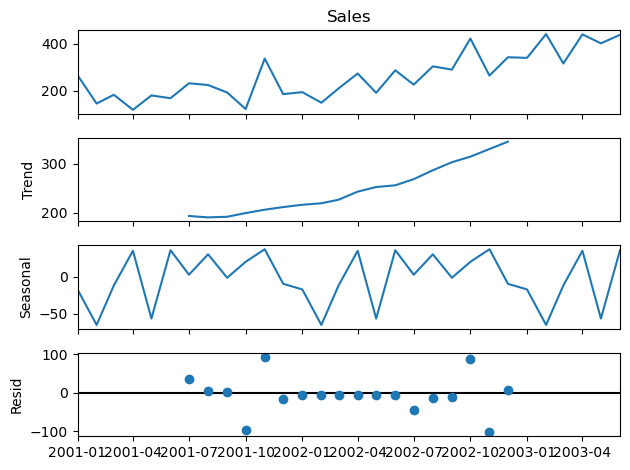

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(train_df[value_var], model='additive')  
fig = plt.figure(figsize=(20,8))  
decomposition.plot()  
plt.show()

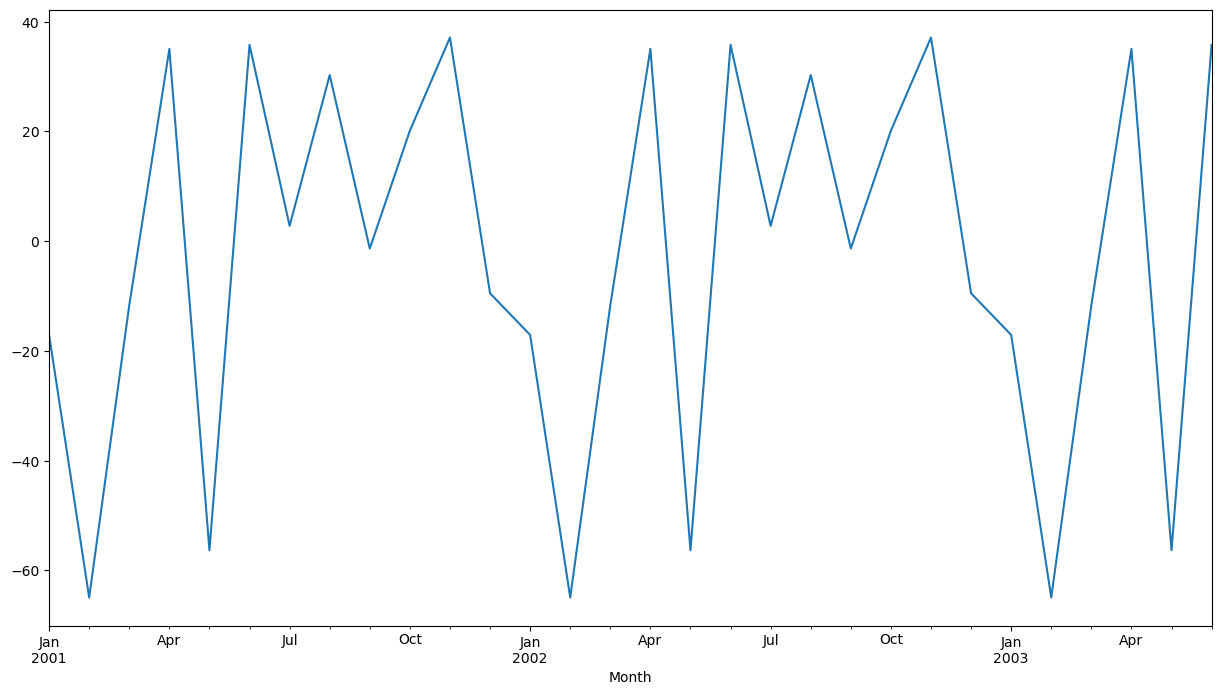

In [16]:
fig = plt.figure(figsize=(15,8))  
decomposition.seasonal.plot()
plt.show()

In [17]:
# From the plot above, we can see that seasonal pattern lasts for 12 months (1 year)
# Set selected_s for ARIMA model
selected_s = 12

### Find differencing d 

In [18]:
from statsmodels.tsa.stattools import adfuller # ADF test
result = adfuller(train_df[value_var])
result

(np.float64(0.4873059070996335),
 np.float64(0.9844821197389604),
 3,
 26,
 {'1%': np.float64(-3.7112123008648155),
  '5%': np.float64(-2.981246804733728),
  '10%': np.float64(-2.6300945562130176)},
 np.float64(223.37243316548202))

In [19]:
def test_adfuller(series, alpha=0.05):
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value}")
    if result[1] <= alpha:
        print("Reject the null hypothesis. Data is stationary")
    else:
        print("Do not reject the null hypothesis. Data is not stationary ")

In [20]:
test_adfuller(train_df[value_var])

ADF Statistic: 0.4873059070996335
p-value: 0.9844821197389604
Critical Value (1%): -3.7112123008648155
Critical Value (5%): -2.981246804733728
Critical Value (10%): -2.6300945562130176
Do not reject the null hypothesis. Data is not stationary 


In [21]:
train_df['first_difference'] = (train_df[value_var] - train_df[value_var].shift(1)).dropna()
# or you can use df[value_var].diff().dropna()  # diff() = compute difference between t and t-1
train_df['first_difference'].head()

Month
2001-01-01      NaN
2001-02-01   -120.1
2001-03-01     37.2
2001-04-01    -63.8
2001-05-01     61.0
Name: first_difference, dtype: float64

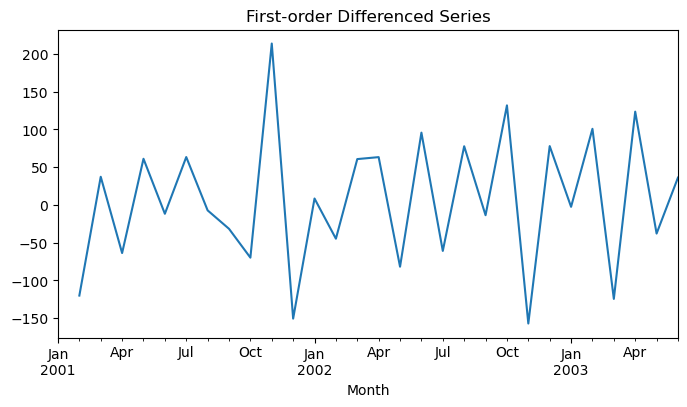

In [22]:
train_df['first_difference'].plot(title="First-order Differenced Series", figsize=(8,4))
plt.show()

In [23]:
test_adfuller(train_df['first_difference'].dropna())

ADF Statistic: -6.4265240576800675
p-value: 1.7390606693039065e-08
Critical Value (1%): -3.7112123008648155
Critical Value (5%): -2.981246804733728
Critical Value (10%): -2.6300945562130176
Reject the null hypothesis. Data is stationary


In [24]:
# Not needed in this example but to show how to find second difference
train_df['second_difference'] = train_df['first_difference'] - train_df['first_difference'].shift(1)
train_df['second_difference'].head()

Month
2001-01-01      NaN
2001-02-01      NaN
2001-03-01    157.3
2001-04-01   -101.0
2001-05-01    124.8
Name: second_difference, dtype: float64

In [25]:
# Set selected_d for ARIMA/SARIMA model
selected_d = 1

### Find differencing D for seasonal timeseries 

In [26]:
# Skip this section if timeseries is not seasonal

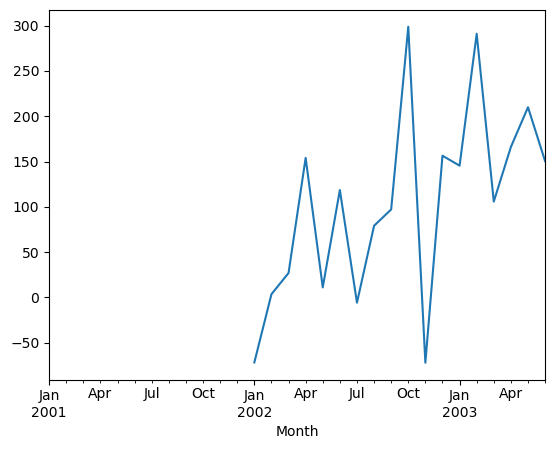

In [27]:
train_df['seasonal_difference'] = train_df[value_var] - train_df[value_var].shift(selected_s)
train_df['seasonal_difference'].plot()
plt.show()

In [28]:
test_adfuller(train_df['seasonal_difference'].dropna())

ADF Statistic: 1.279973000900732
p-value: 0.9964944152515257
Critical Value (1%): -4.223238279489106
Critical Value (5%): -3.189368925619835
Critical Value (10%): -2.729839421487603
Do not reject the null hypothesis. Data is not stationary 


<Axes: xlabel='Month'>

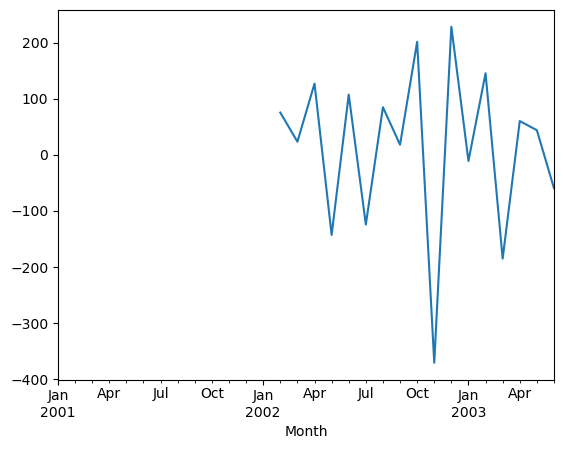

In [29]:
train_df['seasonal_first_difference'] = train_df['first_difference'] - train_df['first_difference'].shift(selected_s)
train_df['seasonal_first_difference'].plot()

In [30]:
test_adfuller(train_df['seasonal_first_difference'].dropna())

ADF Statistic: -4.198280325823906
p-value: 0.0006633306002540565
Critical Value (1%): -4.223238279489106
Critical Value (5%): -3.189368925619835
Critical Value (10%): -2.729839421487603
Reject the null hypothesis. Data is stationary


In [31]:
# Set selected_D for SARIMA model
selected_D = 2

### Identify p and q from PACF and ACF

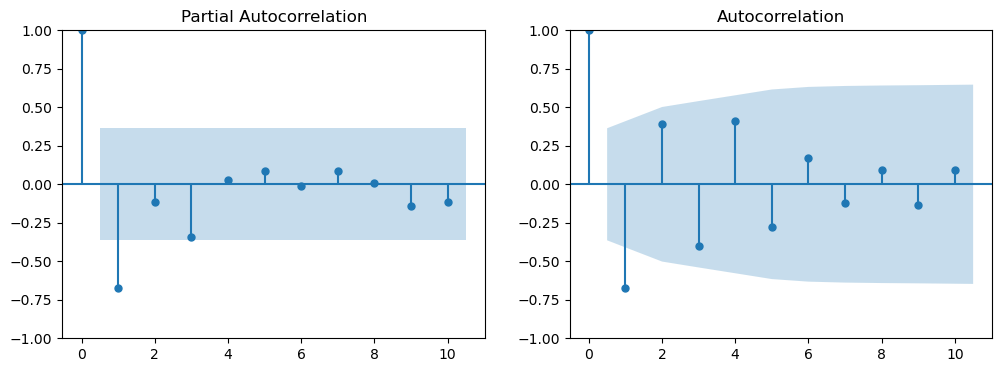

In [32]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

fig, ax = plt.subplots(1, 2, figsize=(12,4))

plot_pacf(train_df['first_difference'].dropna(), lags=10, ax=ax[0])
plot_acf(train_df['first_difference'].dropna(), lags=10, ax=ax[1])

plt.show()

In [33]:
# Set possible selected_p and selected_q for ARIMA/SARIMA model
# the blue area is the confidental region
selected_p = 1 # 0, 1 but 0 is itself
selected_q = 1 # 0, 1 but 0 is itself

### Identify P and Q from PACF and ACF for seasonal timeseries

In [34]:
# Skip this section if timeseries is not seasonal

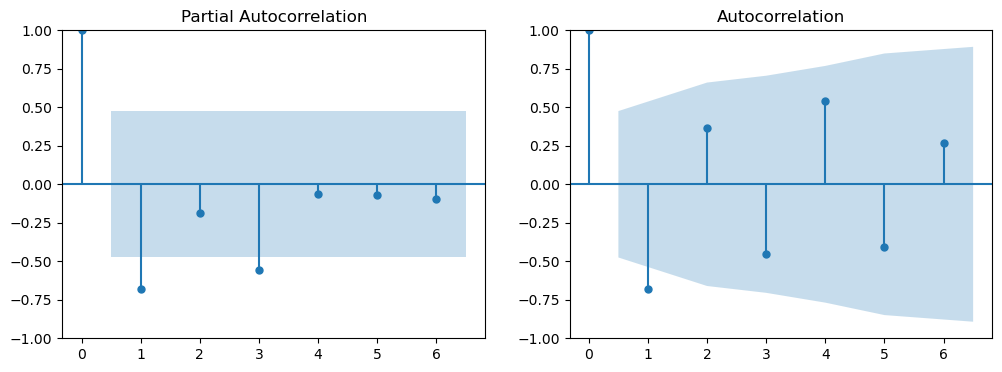

In [35]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

fig, ax = plt.subplots(1, 2, figsize=(12,4))

plot_pacf(train_df['seasonal_first_difference'].dropna(), lags=6, ax=ax[0])
plot_acf(train_df['seasonal_first_difference'].dropna(), lags=6, ax=ax[1])

plt.show()

In [36]:
# Set possible selected_P and selected_Q for SARIMA model
selected_P = 1
selected_Q = 1

### Select ARIMA model based on AIC and BIC

In [37]:
# Set frequeuncy of time index 
# Frequenct String: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
train_df.index = pd.DatetimeIndex(train_df.index, freq='MS')
train_df.index.inferred_freq

'MS'

In [38]:
# Try to construct one model and read result
from statsmodels.tsa.arima.model import ARIMA

print('p: ' + str(selected_p))
print('d: ' + str(selected_d))
print('q: ' + str(selected_q))

model = ARIMA(train_df[value_var], order=(selected_p, selected_d, selected_q))
model_fit = model.fit()

print(model_fit.summary())

#===============================
# ar.L1: Strength of dependence on previous value
#        p-value < 0.05 -> AR term is statistically significant
#                        If insignificant → AR term may be unnecessary
# ma.L1: Captures shock/error correction
#        p-value < 0.05 → MA term contributes meaningfully
#                        If insignificant → MA term may be unnecessary#
# sigma² (noise variance): Variance of residuals
#        Smaller = model explains more structure
#===============================
# Ljung–Box: Test whether residuals are white noise
#            H0: residuals are uncorrelated
#            If p-value (Prob(Q)) > 0.05 -> residuals ≈ white noise -> ARIMA remove all temporal structure
# Heteroskedasticity (H): Test  whether variance of residuals is constant
#                         If p-value (Prob(H)) > 0.05 -> contant variance 
# Jarque-Bera (JB): Test whether residuals are normality
#                   If p-value (Prob(JB)) > 0.05 -> residuals roughly normal
#===============================

p: 1
d: 1
q: 1
                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   30
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -161.746
Date:                Mon, 16 Feb 2026   AIC                            329.492
Time:                        11:38:36   BIC                            333.594
Sample:                    01-01-2001   HQIC                           330.777
                         - 06-01-2003                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4926      0.305     -1.617      0.106      -1.090       0.104
ma.L1         -0.3821      0.264     -1.447      0.148      -0.900       0.136
sigma2      3991.0439   1145.462     

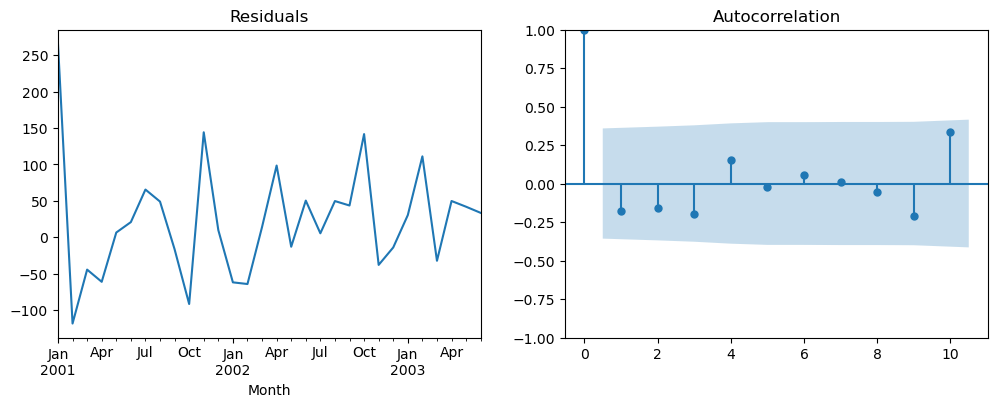

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

residuals = model_fit.resid
residuals.plot(title="Residuals", ax=ax[0])
plot_acf(residuals, lags=10, ax=ax[1])
plt.show()

In [40]:
# Construct multiple models 

In [41]:
print(selected_p, selected_q)

1 1


In [42]:
# Create all possible choices for p and q
start_p = 0
end_p = 2
start_q = 0
end_q = 2

pdq_choices = []
for pi in range(start_p, end_p+1):
    for qi in range(start_q, end_q+1):
        choice = (pi, selected_d, qi)
        pdq_choices.append(choice)
pdq_choices

[(0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (1, 1, 0),
 (1, 1, 1),
 (1, 1, 2),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2)]

In [43]:
from statsmodels.tsa.arima.model import ARIMA

for pdq_choice in pdq_choices:
    #try:
        print(pdq_choice)
        model = ARIMA(train_df[value_var], order=pdq_choice)
        model_fit = model.fit()
    
        # obtain prob(Q), prob(H), prob(JB)
        prob_Q = model_fit.test_serial_correlation(method='ljungbox')[0][1][0]
        prob_H = model_fit.test_heteroskedasticity(method='breakvar')[0][1]
        prob_JB = model_fit.test_normality(method='jarquebera')[0][1]

        print(pdq_choice, ", AIC:", model_fit.aic, ", Prob(Q):", prob_Q, ", Prob(H):", prob_H)
        print(model_fit.pvalues)
    #except:
    #    continue

(0, 1, 0)
(0, 1, 0) , AIC: 344.57716239747754 , Prob(Q): 0.00014296571202561427 , Prob(H): 0.8205564301464029
sigma2    0.000806
dtype: float64
(0, 1, 1)
(0, 1, 1) , AIC: 331.60978013624225 , Prob(Q): 0.08202990485846708 , Prob(H): 0.9488093872382881
ma.L1     0.000230
sigma2    0.000217
dtype: float64
(0, 1, 2)
(0, 1, 2) , AIC: 328.0503658468879 , Prob(Q): 0.23440369100503738 , Prob(H): 0.3383066586500766
ma.L1     0.976404
ma.L2     0.988208
sigma2    0.988166
dtype: float64
(1, 1, 0)
(1, 1, 0) , AIC: 328.80483344303775 , Prob(Q): 0.6461890320977146 , Prob(H): 0.6777847202775208
ar.L1     0.000031
sigma2    0.000313
dtype: float64
(1, 1, 1)
(1, 1, 1) , AIC: 329.49216970573065 , Prob(Q): 0.9468415960752734 , Prob(H): 0.8408627319014137
ar.L1     0.105773
ma.L1     0.148022
sigma2    0.000494
dtype: float64
(1, 1, 2)
(1, 1, 2) , AIC: 329.8808639987199 , Prob(Q): 0.781461208248236 , Prob(H): 0.7577201591949725
ar.L1     0.000014
ma.L1     0.734922
ma.L2     0.240003
sigma2    0.000460
d

/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


#### ARIMA Forecast and Evaluation

In [44]:
# Choose few choices of (p,q) to make predictions and evaluate results

In [45]:
# Model 1
pdq_choice = (1,1,0)

model = ARIMA(train_df[value_var], order=pdq_choice)
model_fit = model.fit()
forecast = model_fit.forecast(steps=forecast_steps)

# aligne index
forecast.index = test_df.index

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test_df[value_var], forecast))
mae = mean_absolute_error(test_df[value_var], forecast)

print(pdq_choice, ", RMSE:", rmse, ", MAE :", mae)

(1, 1, 0) , RMSE: 170.5726562039164 , MAE : 146.94417946328645


In [46]:
# Model 2
pdq_choice = (2,1,0)

model = ARIMA(train_df[value_var], order=pdq_choice)
model_fit = model.fit()
forecast = model_fit.forecast(steps=forecast_steps)

# aligne index
forecast.index = test_df.index

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test_df[value_var], forecast))
mae = mean_absolute_error(test_df[value_var], forecast)

print(pdq_choice, ", RMSE:", rmse, ", MAE :", mae)

(2, 1, 0) , RMSE: 169.87586221266196 , MAE : 146.27273622592296


In [47]:
### Let's evaluate model (1,1,0)

In [48]:
pdq_choice = (1,1,0)

model = ARIMA(train_df[value_var], order=pdq_choice)
model_fit = model.fit()
forecast = model_fit.forecast(steps=forecast_steps)
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   30
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -162.402
Date:                Mon, 16 Feb 2026   AIC                            328.805
Time:                        11:38:37   BIC                            331.539
Sample:                    01-01-2001   HQIC                           329.661
                         - 06-01-2003                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6854      0.165     -4.163      0.000      -1.008      -0.363
sigma2      4196.3972   1164.311      3.604      0.000    1914.390    6478.404
Ljung-Box (L1) (Q):                   0.21   Jarque-

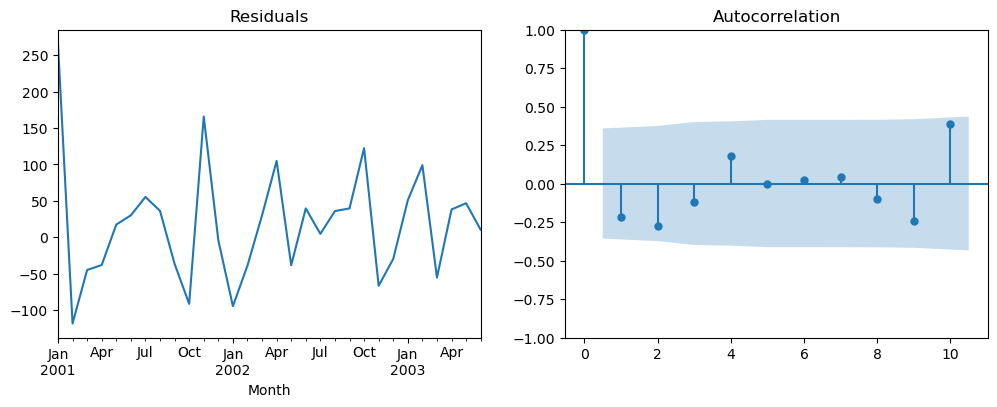

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

residuals = model_fit.resid
residuals.plot(title="Residuals", ax=ax[0])
plot_acf(residuals, lags=10, ax=ax[1])
plt.show()

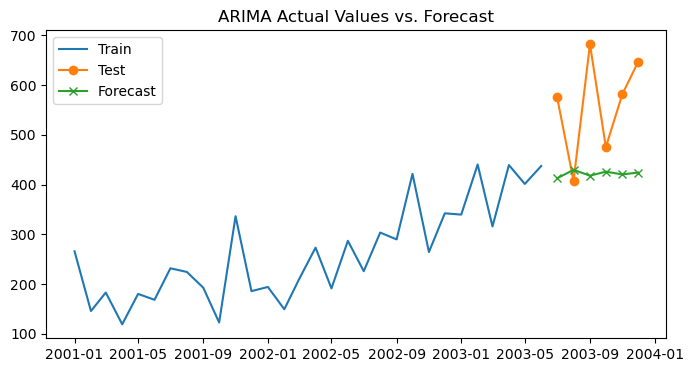

In [50]:
plt.figure(figsize=(8,4))
plt.plot(train_df[value_var], label="Train")
plt.plot(test_df[value_var], label="Test", marker="o")
plt.plot(test_df.index, forecast, label="Forecast", marker="x")
plt.legend()
plt.title("ARIMA Actual Values vs. Forecast")
plt.show()

### Select SARIMA model based on AIC and BIC

In [51]:
# Set frequeuncy of time index 
# Frequenct String: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
train_df.index = pd.DatetimeIndex(train_df.index, freq='MS')
train_df.index.inferred_freq

'MS'

In [52]:
print(selected_s, selected_d, selected_D)
print(selected_p, selected_q)
print(selected_P, selected_Q)

12 1 2
1 1
1 1


In [53]:
# Create all possible choices for p and q
start_p = 1
end_p = 1
start_q = 0
end_q = 1
start_P = 0
end_P = 2
start_Q = 0
end_Q = 2

pdq_choices = []
for pi in range(start_p, end_p+1):
    for qi in range(start_q, end_q+1):
        for Pi in range(start_P, end_P+1):
            for Qi in range(start_Q, end_Q+1):
                pdq_choice = (pi, selected_d, qi)
                PDQ_choice = (Pi, selected_D, Qi, selected_s)
                
                pdq_choices.append([pdq_choice, PDQ_choice])
print(pdq_choices)

[[(1, 1, 0), (0, 2, 0, 12)], [(1, 1, 0), (0, 2, 1, 12)], [(1, 1, 0), (0, 2, 2, 12)], [(1, 1, 0), (1, 2, 0, 12)], [(1, 1, 0), (1, 2, 1, 12)], [(1, 1, 0), (1, 2, 2, 12)], [(1, 1, 0), (2, 2, 0, 12)], [(1, 1, 0), (2, 2, 1, 12)], [(1, 1, 0), (2, 2, 2, 12)], [(1, 1, 1), (0, 2, 0, 12)], [(1, 1, 1), (0, 2, 1, 12)], [(1, 1, 1), (0, 2, 2, 12)], [(1, 1, 1), (1, 2, 0, 12)], [(1, 1, 1), (1, 2, 1, 12)], [(1, 1, 1), (1, 2, 2, 12)], [(1, 1, 1), (2, 2, 0, 12)], [(1, 1, 1), (2, 2, 1, 12)], [(1, 1, 1), (2, 2, 2, 12)]]


In [54]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# from statsmodels.stats.diagnostic import acorr_ljungbox
# from statsmodels.stats.diagnostic import het_arch
# from statsmodels.stats.stattools import jarque_bera

for pdq_choice in pdq_choices:
    try:
        print(pdq_choice)
        model = SARIMAX(train_df[value_var],order=pdq_choice[0], seasonal_order=pdq_choice[1])
        model_fit = model.fit()
        
        # obtain prob(Q)
        # lb = acorr_ljungbox(model_fit.resid, lags=[10], return_df=True)
        # prob_Q = lb['lb_pvalue'].iloc[0]
        # obtain prob(H)
        # prob_H = het_arch(model_fit.resid)[1]
        # obtain prob(JB)
        # jb_stat, prob_JB, skew, kurt = jarque_bera(model_fit.resid)

        # obtain prob(Q), prob(H), prob(JB)
        prob_Q = model_fit.test_serial_correlation(method='ljungbox')[0][1][0]
        prob_H = model_fit.test_heteroskedasticity(method='breakvar')[0][1]
        prob_JB = model_fit.test_normality(method='jarquebera')[0][1]
    
        print(pdq_choice, ", AIC:", model_fit.aic, ", Prob(Q):", prob_Q, ", Prob(H):", prob_H)
        print(model_fit.pvalues)
    except:
        continue

[(1, 1, 0), (0, 2, 0, 12)]
[(1, 1, 0), (0, 2, 0, 12)] , AIC: 67.50485263698675 , Prob(Q): 0.29302465727391014 , Prob(H): 0.949809798270558
ar.L1     0.340446
sigma2    0.517534
dtype: float64
[(1, 1, 0), (0, 2, 1, 12)]
[(1, 1, 0), (0, 2, 1, 12)] , AIC: 69.38534478331468 , Prob(Q): 0.30619528387687217 , Prob(H): 0.8974754915368163
ar.L1       0.425941
ma.S.L12    0.996981
sigma2      0.996801
dtype: float64
[(1, 1, 0), (0, 2, 2, 12)]


/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


[(1, 1, 0), (0, 2, 2, 12)] , AIC: 71.36113978659625 , Prob(Q): 0.309737792087195 , Prob(H): 0.8825144724680423
ar.L1       0.414749
ma.S.L12    0.990709
ma.S.L24    0.996893
sigma2      0.000000
dtype: float64
[(1, 1, 0), (1, 2, 0, 12)]


/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


[(1, 1, 0), (1, 2, 0, 12)] , AIC: 69.38288912690822 , Prob(Q): 0.30741155858893787 , Prob(H): 0.8828431432266394
ar.L1       0.562285
ar.S.L12    0.967090
sigma2      0.998808
dtype: float64
[(1, 1, 0), (1, 2, 1, 12)]
[(1, 1, 0), (1, 2, 1, 12)] , AIC: 71.3683321940265 , Prob(Q): 0.30897162838096826 , Prob(H): 0.8833192201413064
ar.L1       0.458558
ar.S.L12    0.992640
ma.S.L12    0.993279
sigma2      0.000000
dtype: float64
[(1, 1, 0), (1, 2, 2, 12)]


...

/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


[(1, 1, 1), (1, 2, 2, 12)] , AIC: 94.12123230123697 , Prob(Q): 0.341460587287949 , Prob(H): 0.7278393515206826
ar.L1       0.820823
ma.L1       0.998525
ar.S.L12    0.999075
ma.S.L12    1.000000
ma.S.L24    0.998987
sigma2      0.000123
dtype: float64
[(1, 1, 1), (2, 2, 0, 12)]
[(1, 1, 1), (2, 2, 1, 12)]


/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


[(1, 1, 1), (2, 2, 1, 12)] , AIC: 74.99117677060384 , Prob(Q): 0.2778848823173038 , Prob(H): 0.6684668266407278
ar.L1       0.983016
ma.L1       0.897324
ar.S.L12    0.999952
ar.S.L24    0.997720
ma.S.L12    0.999919
sigma2      0.942058
dtype: float64
[(1, 1, 1), (2, 2, 2, 12)]
[(1, 1, 1), (2, 2, 2, 12)] , AIC: 77.4081446355397 , Prob(Q): 0.3057140201817126 , Prob(H): 0.8038855608096052
ar.L1       8.559901e-01
ma.L1       9.504869e-01
ar.S.L12    9.999237e-01
ar.S.L24    9.982217e-01
ma.S.L12    9.914249e-01
ma.S.L24    9.954223e-01
sigma2      3.068284e-27
dtype: float64


/nix/store/4kvfh546lkidwf9inrwq5g9zhrcwm9va-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [55]:
# Choose few choices of (p,q) and P,D) to make predictions and evaluate results

[(1, 1, 0), (0, 1, 0, 12)] , RMSE: 144.24523874376692 , MAE : 136.80017046289444


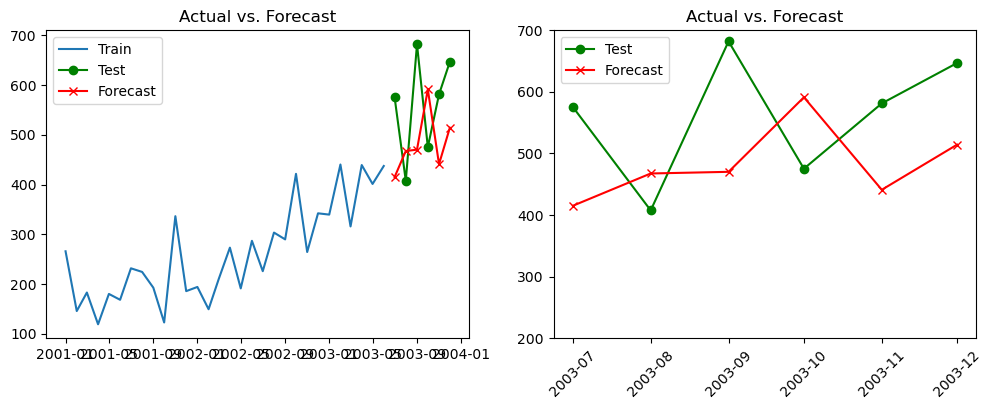

In [56]:
# Model 1
pdq_choice = [(1,1,0), (0,1,0,12)]

model = SARIMAX(train_df[value_var],order=pdq_choice[0], seasonal_order=pdq_choice[1])
model_fit = model.fit()
forecast = model_fit.forecast(steps=forecast_steps)

# aligne index
forecast.index = test_df.index

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test_df[value_var], forecast))
mae = mean_absolute_error(test_df[value_var], forecast)

print(pdq_choice, ", RMSE:", rmse, ", MAE :", mae)

fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(train_df[value_var], label="Train")
ax[0].plot(test_df[value_var], label="Test", marker="o", color='green')
ax[0].plot(test_df.index, forecast, label="Forecast", marker="x", color='red')
ax[0].legend()
ax[0].set_title("Actual vs. Forecast")

ax[1].plot(test_df[value_var], label="Test", marker="o", color='green')
ax[1].plot(test_df.index, forecast, label="Forecast", marker="x", color='red')
ax[1].legend()
ax[1].set_title("Actual vs. Forecast")
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylim([200, 700])
    
plt.show()

[(1, 1, 0), (1, 1, 0, 12)] , RMSE: 144.89588947549242 , MAE : 122.29670608235033


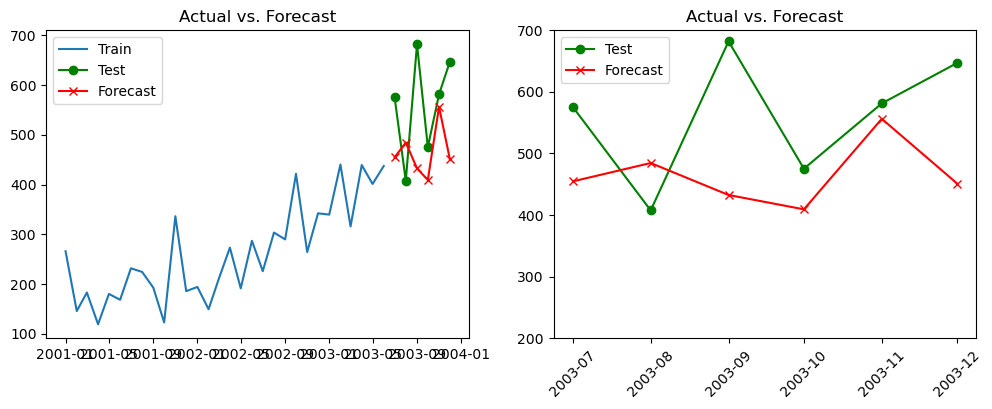

In [57]:
# Model 2
pdq_choice = [(1,1,0), (1,1,0,12)]

model = SARIMAX(train_df[value_var],order=pdq_choice[0], seasonal_order=pdq_choice[1])
model_fit = model.fit()
forecast = model_fit.forecast(steps=forecast_steps)

# aligne index
forecast.index = test_df.index

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test_df[value_var], forecast))
mae = mean_absolute_error(test_df[value_var], forecast)

print(pdq_choice, ", RMSE:", rmse, ", MAE :", mae)

fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(train_df[value_var], label="Train")
ax[0].plot(test_df[value_var], label="Test", marker="o", color='green')
ax[0].plot(test_df.index, forecast, label="Forecast", marker="x", color='red')
ax[0].legend()
ax[0].set_title("Actual vs. Forecast")

ax[1].plot(test_df[value_var], label="Test", marker="o", color='green')
ax[1].plot(test_df.index, forecast, label="Forecast", marker="x", color='red')
ax[1].legend()
ax[1].set_title("Actual vs. Forecast")
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylim([200, 700])
    
plt.show()

In [58]:
### Let's evaluate one model [(1, 1, 0), (1, 1, 0, 12)]

In [59]:
pdq_choice = [(1, 1, 0), (1, 1, 0, 12)]

model = SARIMAX(train_df[value_var],order=pdq_choice[0], seasonal_order=pdq_choice[1])
model_fit = model.fit()
forecast = model_fit.forecast(steps=forecast_steps)
print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   30
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                -102.749
Date:                            Mon, 16 Feb 2026   AIC                            211.497
Time:                                    11:38:46   BIC                            213.997
Sample:                                01-01-2001   HQIC                           211.746
                                     - 06-01-2003                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8762      0.210     -4.170      0.000      -1.288      -0.464
ar.S.L12      -0.8670      0.231   

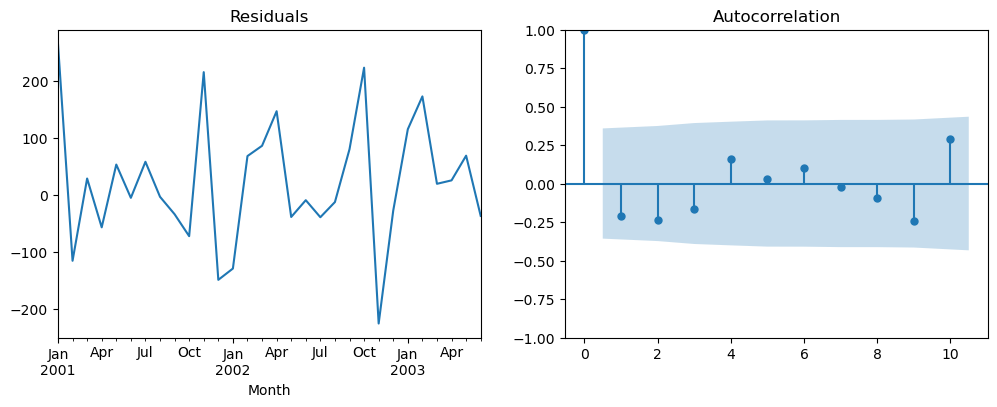

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

residuals = model_fit.resid
residuals.plot(title="Residuals", ax=ax[0])
plot_acf(residuals, lags=10, ax=ax[1])
plt.show()

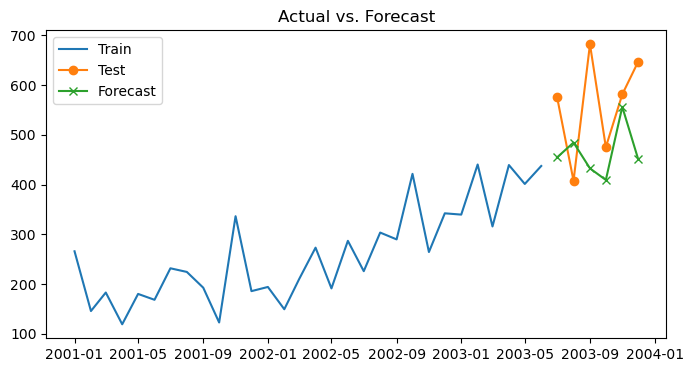

In [61]:
plt.figure(figsize=(8,4))
plt.plot(train_df[value_var], label="Train")
plt.plot(test_df[value_var], label="Test", marker="o")
plt.plot(test_df.index, forecast, label="Forecast", marker="x")
plt.legend()
plt.title("Actual vs. Forecast")
plt.show()

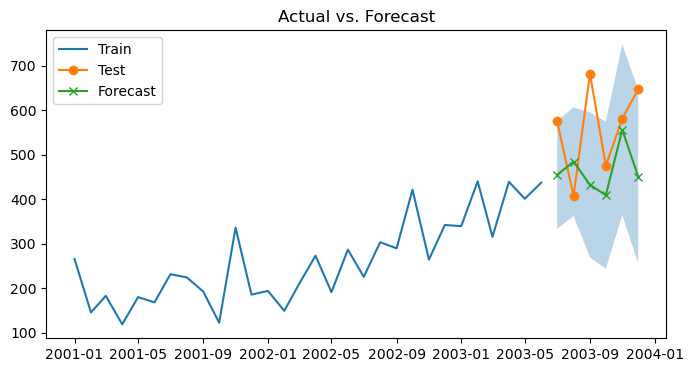

In [62]:
# Plot with confidence intervals of forecasting values

plt.figure(figsize=(8,4))

# Confidence intervals
model_forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = model_forecast.predicted_mean                 # Predicted values, same result as model_fit.forecast(steps=forecast_steps)
forecast_ci = model_forecast.conf_int()

plt.plot(train_df[value_var], label="Train")
plt.plot(test_df[value_var], label="Test", marker="o")
plt.plot(forecast_mean, label="Forecast", marker="x")

# Plot confidence intervals
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.legend()
plt.title("Actual vs. Forecast")
plt.show()